<a href="https://colab.research.google.com/github/Rytham1/song-popularity-predictor/blob/main/ecs_171_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import os
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Loading Dataset + EDA

In [2]:
# Download latest version
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

print("Path to dataset files:", path)

path = "/kaggle/input/30000-spotify-songs/spotify_songs.csv"

df = pd.read_csv(path)
df.head()

Using Colab cache for faster access to the '30000-spotify-songs' dataset.
Path to dataset files: /kaggle/input/30000-spotify-songs


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## EDA

In [3]:
print("df.shape:", df.shape)

dupe_song = df.duplicated(subset=["track_name", "track_artist"]).sum()
print("Duplicates by (track_name, track_artist):", dupe_song)

dupe_id = df.duplicated(subset=["track_id"]).sum()
print("Duplicates by track_id:", dupe_id)

df.shape: (32833, 23)
Duplicates by (track_name, track_artist): 6603
Duplicates by track_id: 4477


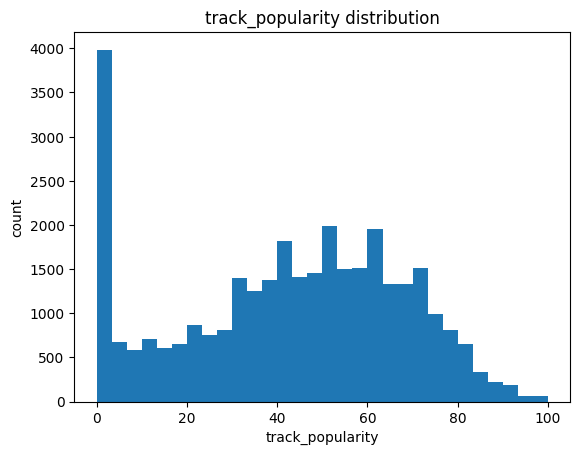

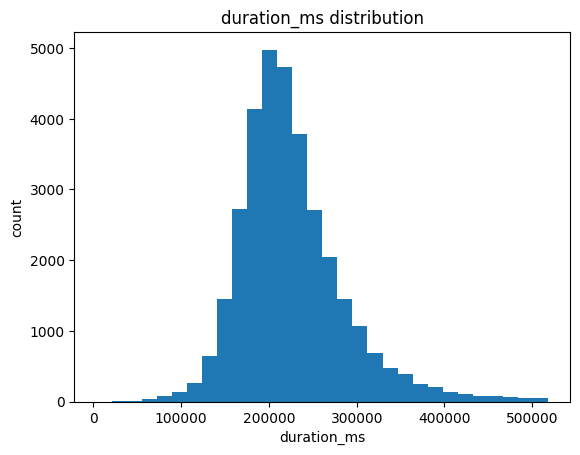

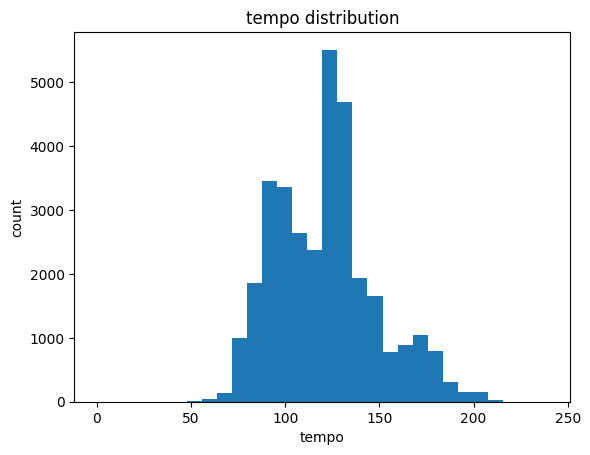

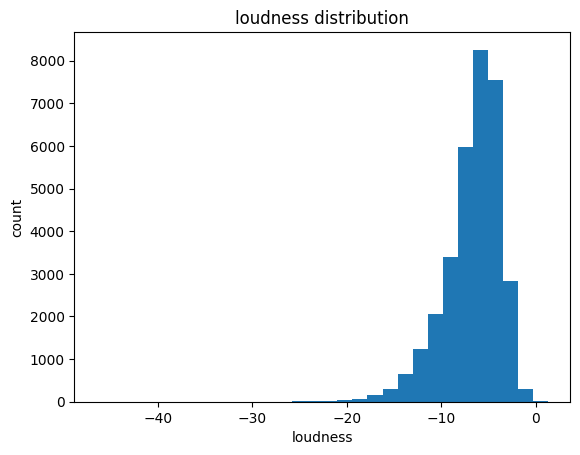

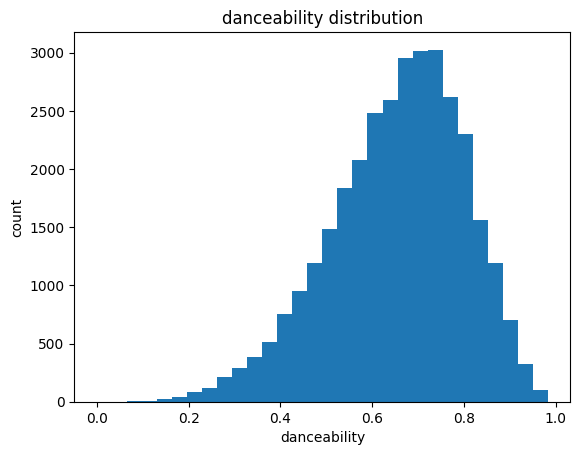

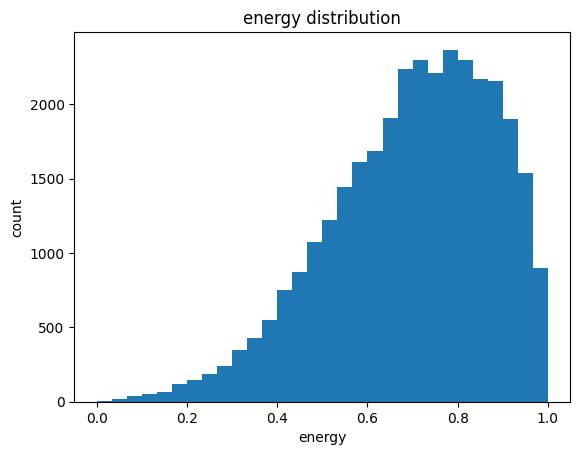

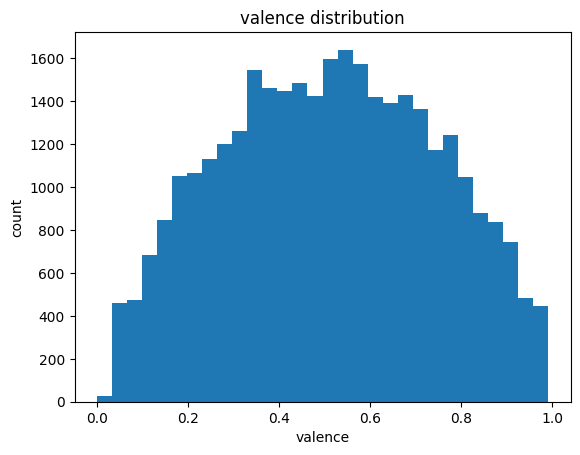

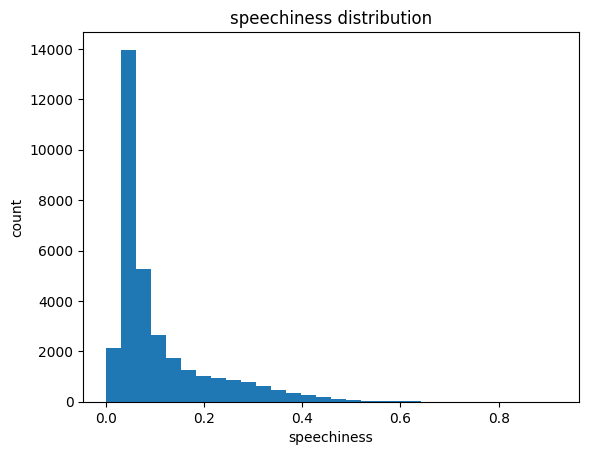

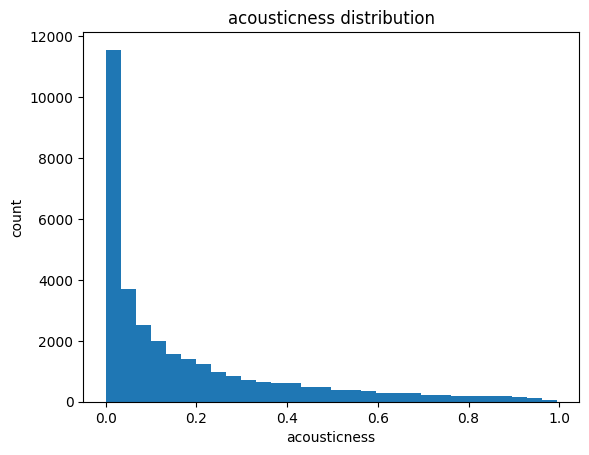

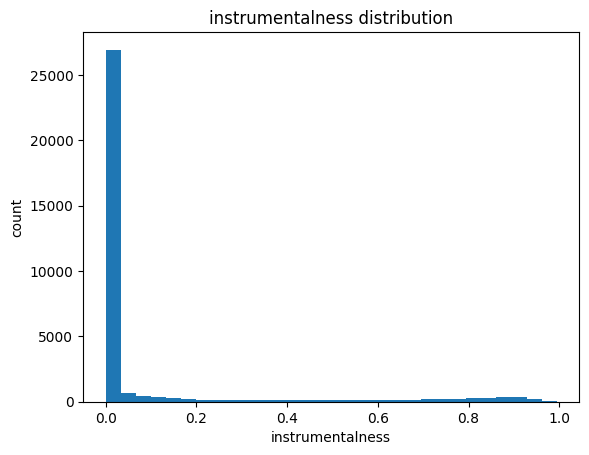

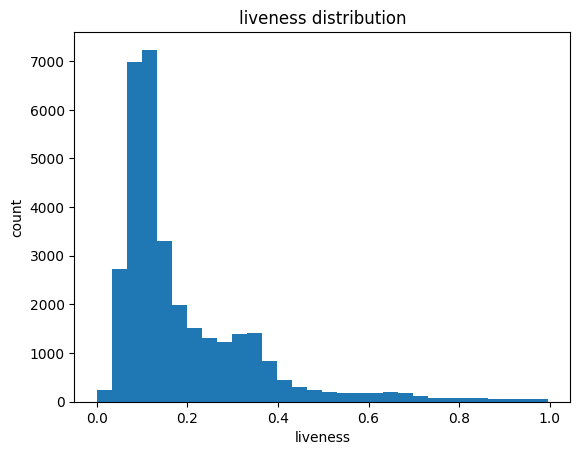

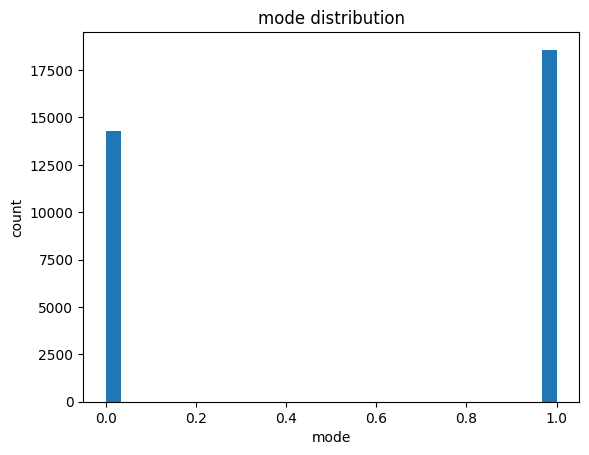

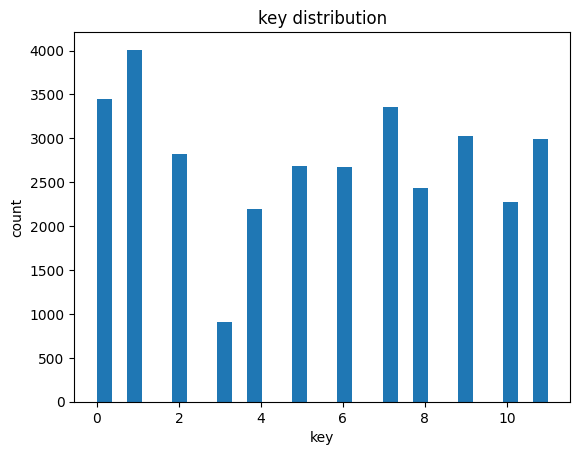

In [4]:
features = [f for f in ["track_popularity","duration_ms","tempo","loudness","danceability","energy","valence","speechiness","acousticness","instrumentalness","liveness","mode","key"]]
for f in features:
    plt.figure()
    plt.hist(df[f].dropna(), bins=30)
    plt.title(f"{f} distribution")
    plt.xlabel(f)
    plt.ylabel("count")
    plt.show()


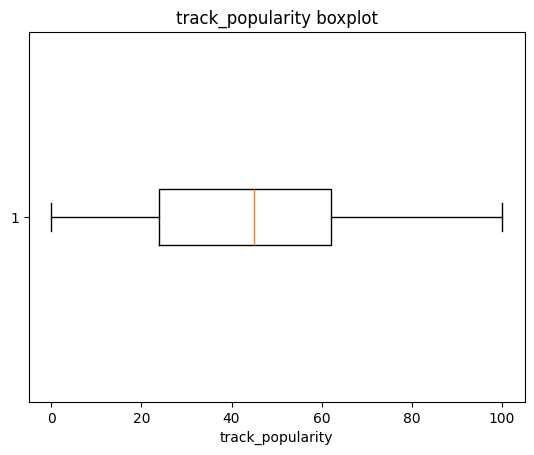

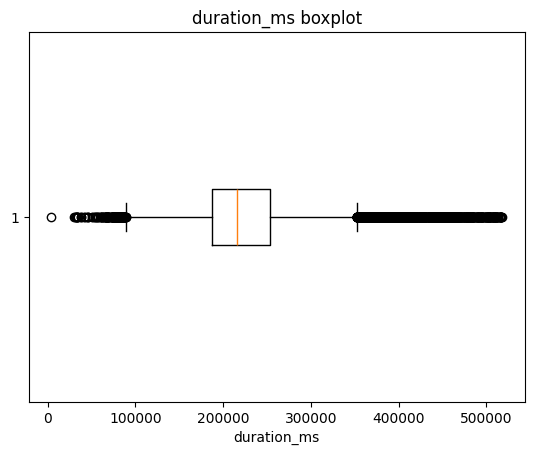

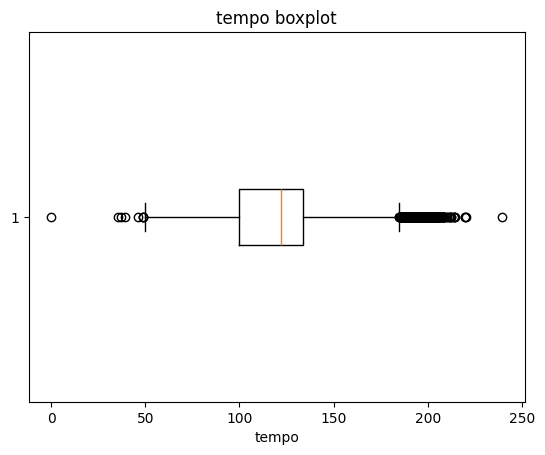

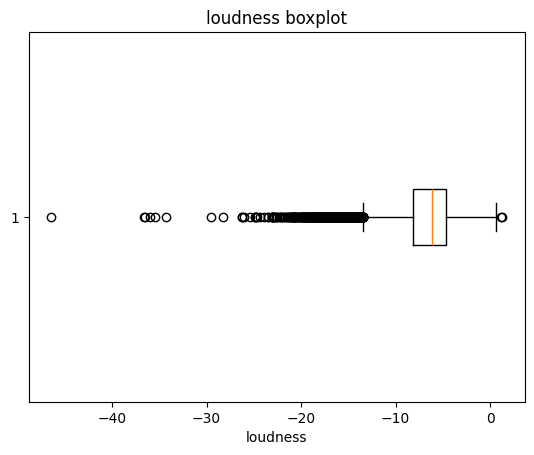

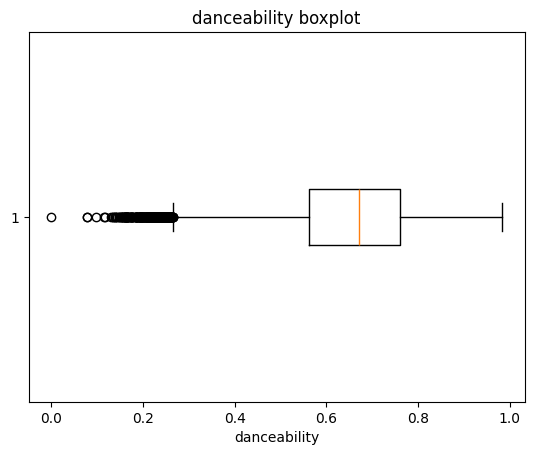

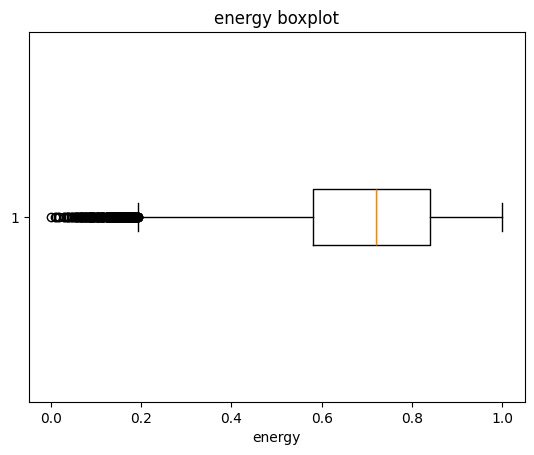

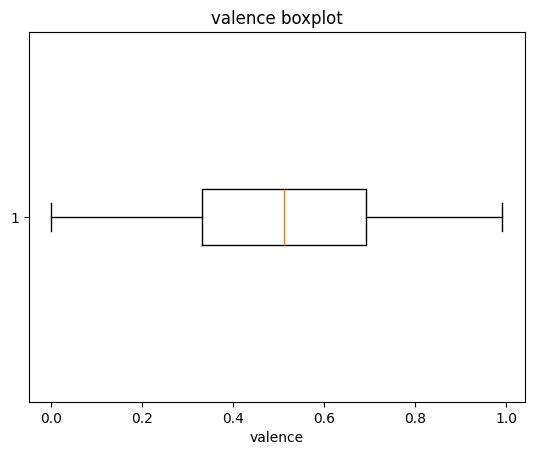

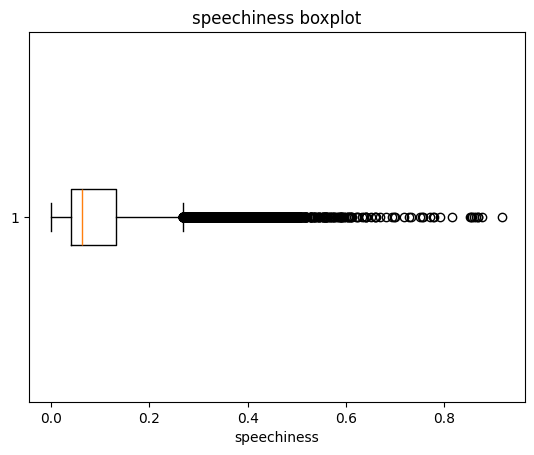

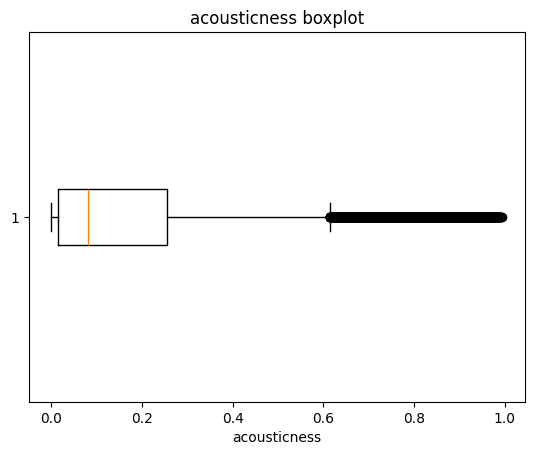

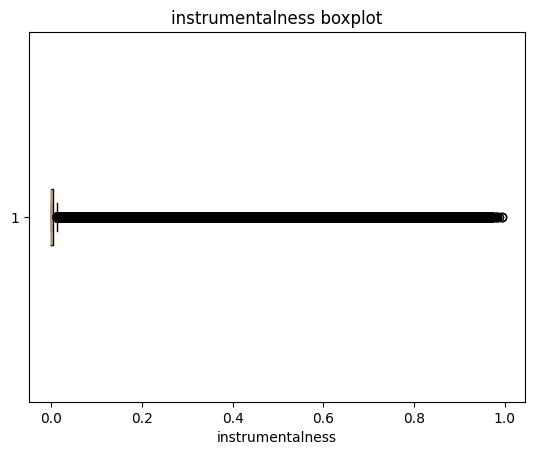

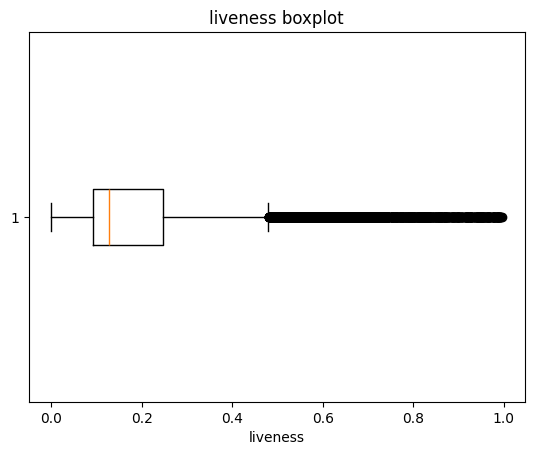

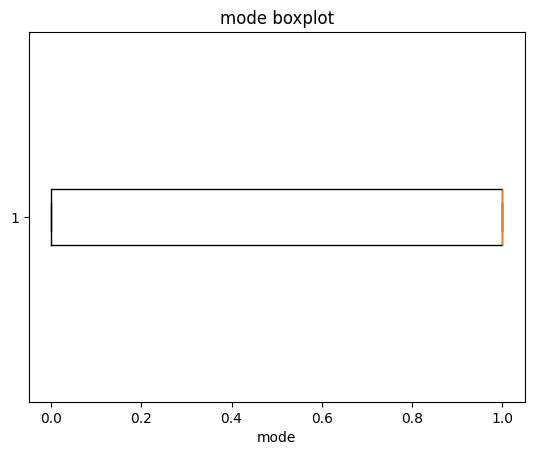

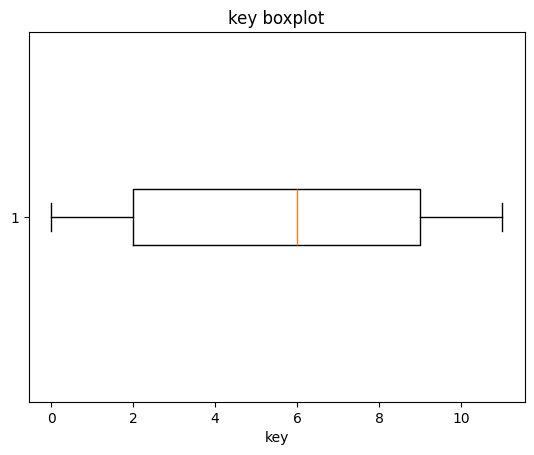

In [5]:
features = [f for f in ["track_popularity","duration_ms","tempo","loudness","danceability","energy","valence","speechiness","acousticness","instrumentalness","liveness","mode","key"]]

for f in features:
    plt.figure()
    plt.boxplot(df[f].dropna(), vert=False, showfliers=True)  # showfliers=True shows outliers
    plt.title(f"{f} boxplot")
    plt.xlabel(f)
    plt.show()

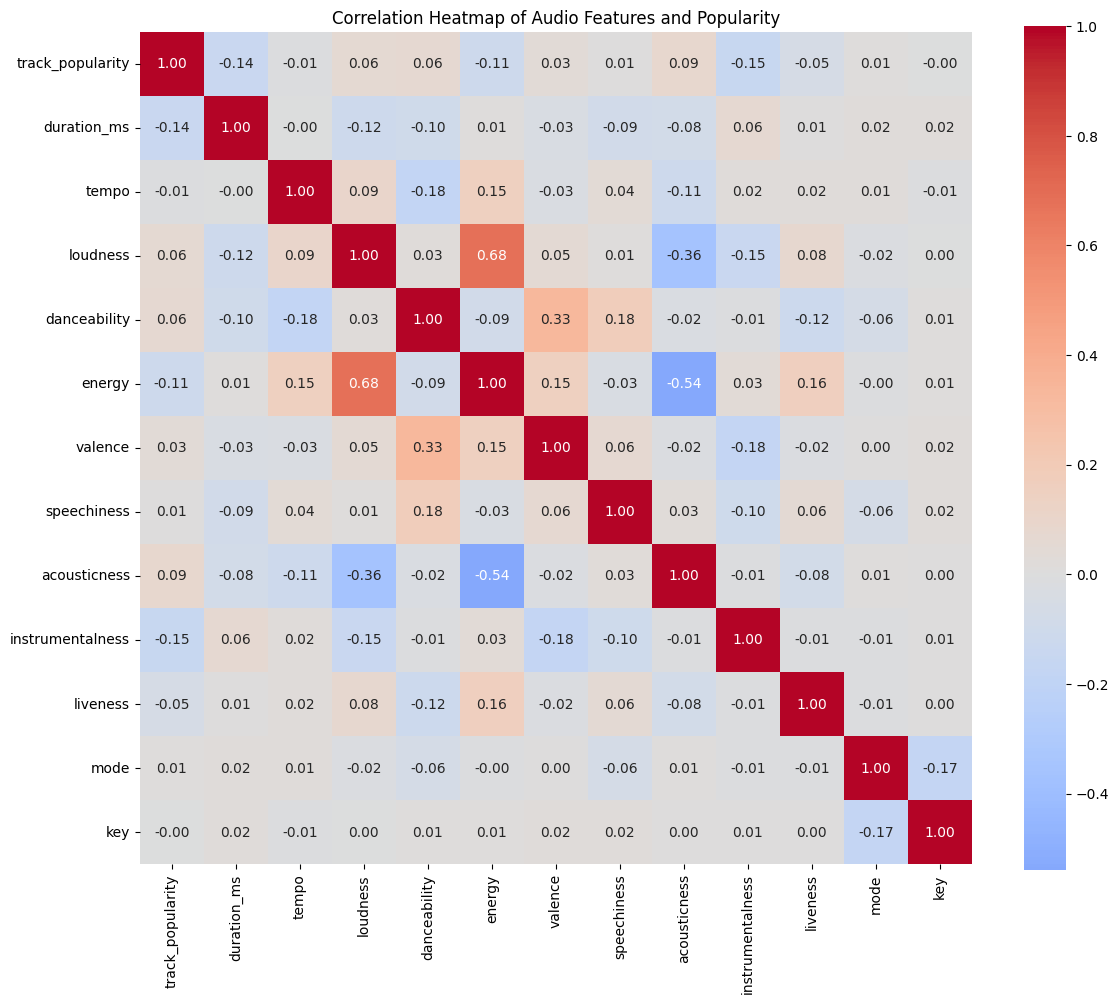

In [6]:
features = [f for f in ["track_popularity","duration_ms","tempo","loudness","danceability","energy","valence","speechiness","acousticness","instrumentalness","liveness","mode","key"]]
correlation_matrix = df[features].corr()
plt.figure(figsize = (12, 10))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm",
            center = 0, square = True)
plt.title("Correlation Heatmap of Audio Features and Popularity")
plt.tight_layout()
plt.show()


## Feature Selection + Model Development

In [7]:
"""
Checking how many unique artists we have.
Artist name is imporant for track popularity but if it is too many unique values, we have to drop it.
This is because, we will have to do one-hot-encoding, leading to too many columns.
"""

unique_artists = df["track_artist"].nunique()
print("unique values for artists: ", unique_artists)

# we should one hot encode this since it is low (6 unique)
unique_genre= df["playlist_genre"].nunique()
print("unique values for genre: ", unique_genre)

# same here, one hot encode this (24 unique)
unique_subgenre = df["playlist_subgenre"].nunique()
print("unique values for subgenre: ", unique_subgenre)

unique values for artists:  10692
unique values for genre:  6
unique values for subgenre:  24


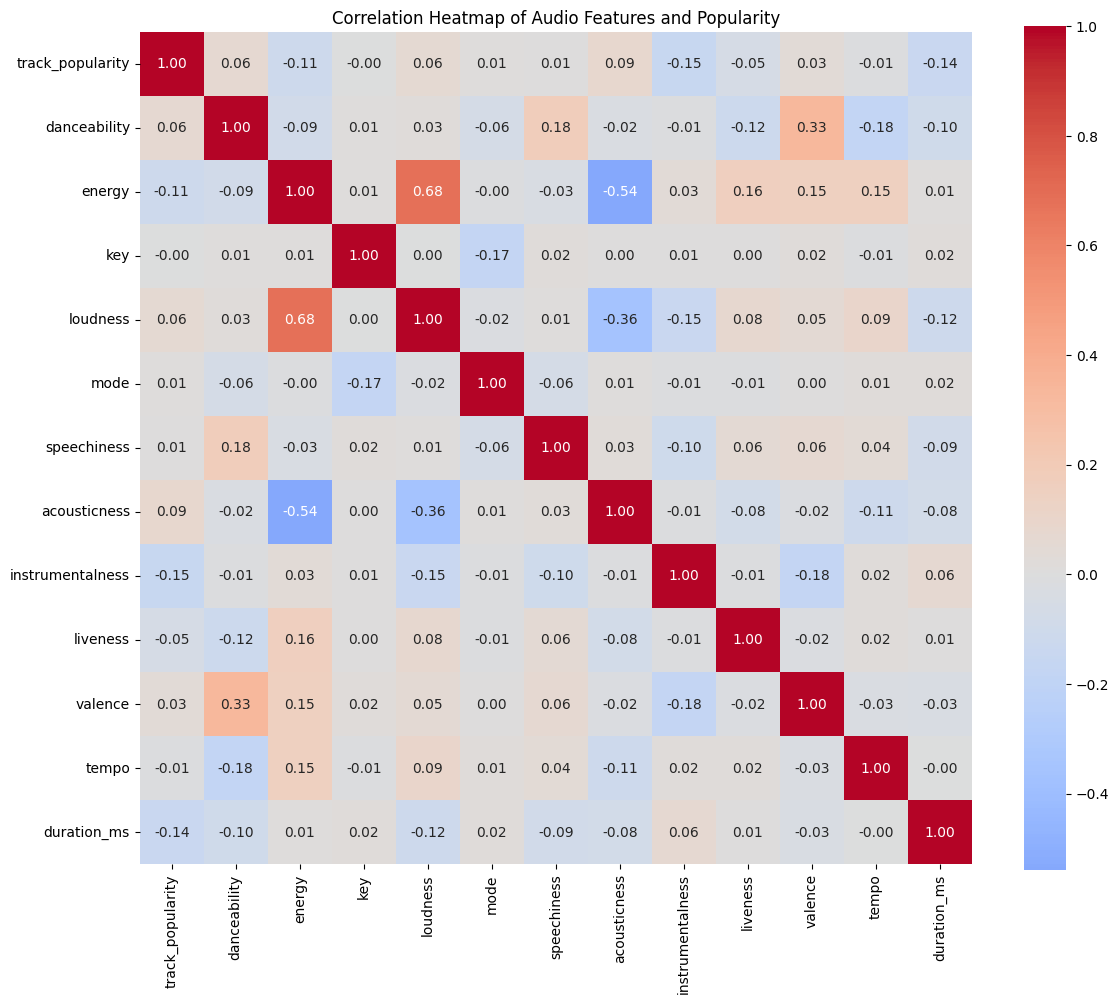

In [8]:
# Correlation matrix for all features that have numerical values
numeric_df = df.select_dtypes(include=['number'])
full_correlation_matrix = numeric_df.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(full_correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm",
            center = 0, square = True)
plt.title("Correlation Heatmap of Audio Features and Popularity")
plt.tight_layout()
plt.show()

In [9]:
# Extracing the year from release data to see how it correlates with popularity
print(df['track_album_release_date'])
df['release_year'] = (pd.to_datetime(df["track_album_release_date"], format="mixed")).dt.year

print("\n Extracted year from Date: \n")
print(df['release_year'])

# doing the correlation with year and popularity
print(df[['release_year', 'track_popularity']].corr())

# Conclusion: Drop the track_album_release_date, low correlation

0        2019-06-14
1        2019-12-13
2        2019-07-05
3        2019-07-19
4        2019-03-05
            ...    
32828    2014-04-28
32829    2013-03-08
32830    2014-04-21
32831    2014-01-01
32832    2014-03-03
Name: track_album_release_date, Length: 32833, dtype: object

 Extracted year from Date: 

0        2019
1        2019
2        2019
3        2019
4        2019
         ... 
32828    2014
32829    2013
32830    2014
32831    2014
32832    2014
Name: release_year, Length: 32833, dtype: int32
                  release_year  track_popularity
release_year          1.000000          0.060744
track_popularity      0.060744          1.000000


##Data Preprocessing

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

selected_feature_columns = [
    "track_popularity",
    "duration_ms",
    "tempo",
    "loudness",
    "danceability",
    "energy",
    "valence",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "mode",
    "key",
]

target_column = "track_popularity"
model_feature_columns = [
    col for col in selected_feature_columns if col != target_column
]

In [11]:
def compute_iqr_bounds(
    numeric_series: pd.Series, iqr_multiplier: float = 1.5
) -> tuple[float, float]:
    first_quartile = numeric_series.quantile(0.25)
    third_quartile = numeric_series.quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - iqr_multiplier * interquartile_range
    upper_bound = third_quartile + iqr_multiplier * interquartile_range
    return lower_bound, upper_bound


def fit_iqr_outlier_bounds(
    training_features: pd.DataFrame,
    numeric_feature_columns: list[str],
    iqr_multiplier: float = 1.5,
) -> dict[str, tuple[float, float]]:
    feature_to_bounds = {}
    for feature_name in numeric_feature_columns:
        non_null_values = training_features[feature_name].dropna()
        lower_bound, upper_bound = compute_iqr_bounds(
            non_null_values, iqr_multiplier=iqr_multiplier
        )
        feature_to_bounds[feature_name] = (lower_bound, upper_bound)
    return feature_to_bounds


def apply_outlier_clipping(
    feature_frame: pd.DataFrame,
    feature_to_bounds: dict[str, tuple[float, float]],
) -> pd.DataFrame:

    clipped_features = feature_frame.copy()

    for feature_name, (lower_bound, upper_bound) in feature_to_bounds.items():
        clipped_features[feature_name] = clipped_features[feature_name].clip(
            lower_bound, upper_bound
        )

    return clipped_features


def preprocess_split_and_scale(
    raw_dataframe: pd.DataFrame,
    test_fraction: float = 0.2,
    iqr_multiplier: float = 1.5,
):

    working_dataframe = raw_dataframe.copy()

    # remove duplicates
    working_dataframe = working_dataframe.drop_duplicates(
        subset=["track_id"], keep="first"
    )

    working_dataframe = working_dataframe[selected_feature_columns].dropna(
        subset=[target_column]
    )

    # split
    feature_matrix = working_dataframe[model_feature_columns]
    target_vector = working_dataframe[target_column]

    training_features, test_features, training_target, test_target = train_test_split(
        feature_matrix, target_vector, test_size=test_fraction
    )

    # outliers
    fitted_outlier_bounds = fit_iqr_outlier_bounds(
        training_features=training_features,
        numeric_feature_columns=model_feature_columns,
        iqr_multiplier=iqr_multiplier,
    )

    training_features = apply_outlier_clipping(
        feature_frame=training_features, feature_to_bounds=fitted_outlier_bounds
    )

    test_features = apply_outlier_clipping(
        feature_frame=test_features, feature_to_bounds=fitted_outlier_bounds
    )

    # standardize
    fitted_scaler = StandardScaler()
    scaled_training_features = fitted_scaler.fit_transform(training_features)
    scaled_test_features = fitted_scaler.transform(test_features)

    return (
        scaled_training_features,
        scaled_test_features,
        training_target,
        test_target,
        fitted_scaler,
        fitted_outlier_bounds,
    )


def summarize_iqr_outliers(
    raw_dataframe: pd.DataFrame,
    numeric_feature_columns: list[str],
    iqr_multiplier: float = 1.5,
) -> pd.DataFrame:

    summary_rows = []
    for feature_name in numeric_feature_columns:
        non_null_values = raw_dataframe[feature_name].dropna()
        lower_bound, upper_bound = compute_iqr_bounds(
            non_null_values, iqr_multiplier=iqr_multiplier
        )
        non_null_count = raw_dataframe[feature_name].notna().sum()
        outlier_count = (
            (raw_dataframe[feature_name] < lower_bound)
            | (raw_dataframe[feature_name] > upper_bound)
        ).sum()
        outlier_rate = outlier_count / max(non_null_count, 1)
        summary_rows.append(
            {
                "feature_name": feature_name,
                "non_null_count": int(non_null_count),
                "outlier_count": int(outlier_count),
                "outlier_rate": float(outlier_rate),
                "lower_bound": float(lower_bound),
                "upper_bound": float(upper_bound),
            }
        )

    return (
        pd.DataFrame(summary_rows)
        .sort_values("outlier_rate", ascending=False)
        .reset_index(drop=True)
    )

In [15]:
scaled_training_features, scaled_test_features, training_target, test_target, fitted_scaler, fitted_outlier_bounds = preprocess_split_and_scale(raw_dataframe=df)
outlier_summary_table = summarize_iqr_outliers(df, model_feature_columns)
outlier_summary_table.head(10)

,feature_name,non_null_count,outlier_count,outlier_rate,lower_bound,upper_bound
0,instrumentalness,32833,7030,0.214114,-0.007245,0.012075
1,speechiness,32833,3176,0.096732,-0.095500,0.268500
2,acousticness,32833,2205,0.067158,-0.344750,0.614850
3,liveness,32833,1843,0.056133,-0.140250,0.480950
4,duration_ms,32833,1387,0.042244,89170.000000,352234.000000
5,loudness,32833,1021,0.031097,-13.460000,0.644000
6,tempo,32833,571,0.017391,49.023000,184.855000
7,danceability,32833,291,0.008863,0.266000,1.058000
8,energy,32833,277,0.008437,0.192500,1.228500
9,valence,32833,0,0.000000,-0.212000,1.236000


## Models

In [16]:
"""
  scaled_training_features
  scaled_test_features
  training_target
  test_target
"""

X_train = scaled_training_features
X_test = scaled_test_features
y_train = training_target
y_test = test_target

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# KNN MODEL (KNN Regressor): https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Evaluate:
knn_mse = mean_absolute_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN MSE:", knn_mse) # we want low MSE
print("KNN R2:", knn_r2) # we want high r2

KNN MSE: 20.637411847672777
KNN R2: -0.10072310542533902


In [19]:
# BASIC NEURAL NET
from sklearn.neural_network import MLPRegressor

# 3 hidden layers, first two layer 64 neurons, third layer 32 neurons
basic_nn_model = MLPRegressor(hidden_layer_sizes=(64, 64, 32), activation='relu', alpha=0.01, random_state=42, max_iter=250)

basic_nn_model.fit(X_train, y_train)
y_pred_nn = basic_nn_model.predict(X_test)


nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)

print("NN MSE:", nn_mse) # we want low MSE -> MSE punished large errors heavily (squared)
print("NN MAE:", nn_mae) # we want low MAE
print("NN R2:", nn_r2) # we want high r2

# We should do grid search for hyperparam tuning

NN MSE: 566.7211724663579
NN MAE: 19.589052912389473
NN R2: 0.007573506939613339


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
